In [10]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [11]:
# Filter for the job tible and country
df_US = df[(df['job_country']=='United States')].dropna(subset = ['salary_year_avg'])

In [12]:
# Select 6 jobs and add them into the list
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [13]:
# Create another dataframe that contain rows with jobs in the list called job_titles - in this case, there are 6 jobs
df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

In [20]:
# Sort the Y axis by the median yearly salary
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

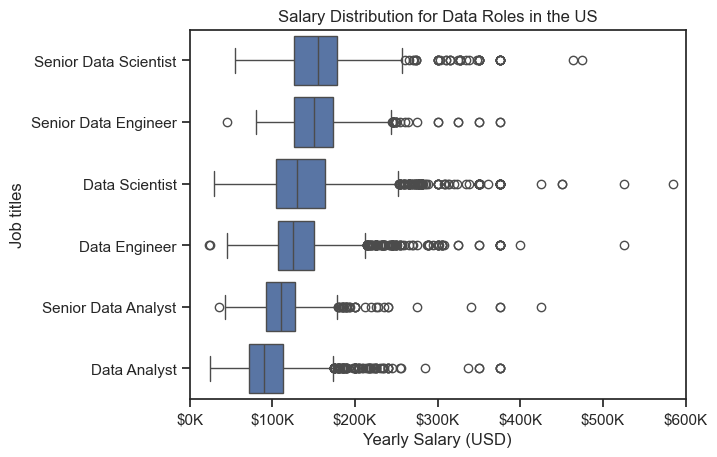

In [21]:
# Create horizontal box plot
sns.boxplot(
    data=df_US_top6,
    x='salary_year_avg',
    y='job_title_short',
    order = job_order
)
sns.set_theme(style = 'ticks')

#set x-axis limit
plt.xlim(0, 600000)

# Format x-axis as $100K
tick_x = plt.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K')
plt.gca().xaxis.set_major_formatter(tick_x)
    
plt.title('Salary Distribution for Data Roles in the US')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Job titles')
plt.show()